<div style="
    text-align: center; 
    background: linear-gradient(135deg, #0062ff 0%, #00d4ff 100%); 
    font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; 
    color: white; 
    padding: 35px 20px; 
    border-radius: 15px; 
    box-shadow: 0 10px 25px rgba(0, 98, 255, 0.3);
    margin-bottom: 25px;">
    <div style="font-size: 35px; font-weight: 800; letter-spacing: 1.5px; text-transform: uppercase; line-height: 1.2;">
        Trực Quan Hóa Dữ Liệu - Lab 01
    </div>
    <div style="font-size: 16px; font-weight: 500; margin-top: 10px; font-style: italic; opacity: 0.9;">
        "Phân tích thị trường mỹ phẩm nội vs ngoại trên Tiki"
    </div>
    <div style="font-size: 18px; font-weight: 600; margin-top: 15px; border-top: 1px solid rgba(255,255,255,0.4); display: inline-block; padding-top: 10px; letter-spacing: 1px;">
        NHÓM 05 - FIT-HCMUS
    </div>
</div>

<div style="text-align: center; font-size: 40px; font-weight: bold;">
  TỔNG QUAN THỊ TRƯỜNG & ĐỘNG LỰC TĂNG TRƯỞNG
</div>

# **1. Thiết lập môi trường và nạp dữ liệu**
## **1.1. Thiết lập môi trường**

In [1]:
# Cài đặt các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style toàn cục cho các biểu đồ
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : False,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
    'figure.dpi'        : 130,
    'savefig.dpi'       : 150,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})

# Bảng màu nhất quán xuyên suốt
C_DOMESTIC = '#2563EB'   # xanh dương — hàng trong nước
C_IMPORT   = '#DC2626'   # đỏ         — hàng ngoài nước
PALETTE    = [C_DOMESTIC, C_IMPORT]
COUNTRY_COLORS = [
    '#EF4444','#F97316','#EAB308','#22C55E','#3B82F6',
    '#8B5CF6','#EC4899','#14B8A6','#F59E0B','#6366F1'
]

print('Các thư viện đã được cài đặt và cấu hình thành công!')

Các thư viện đã được cài đặt và cấu hình thành công!


## **1.2. Nạp dữ liệu**

In [2]:
# 1. Nạp dữ liệu
df = pd.read_csv('../data/tiki_cosmetics_processed.csv')

# 2. Khôi phục thứ tự cho phân khúc giá (để vẽ biểu đồ không bị nhảy lộn xộn)
price_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
df['price_segment'] = pd.Categorical(df['price_segment'], categories=price_order, ordered=True)

# 3. Tập con theo origin_class_corrected (đã hiệu chỉnh ở file preprocessing)
df_vn = df[df['origin_class_corrected'] == 'Trong nước'].copy()
df_nn = df[df['origin_class_corrected'] == 'Ngoài nước'].copy()

# 4. Kiểm tra các chỉ số (ĐÃ FIX LỖI KHOẢNG TRẮNG)
print(f' Tổng sản phẩm : {len(df):,}')
print(f'    Trong nước : {len(df_vn):,} ({len(df_vn)/len(df)*100:.1f}%)')
print(f'    Ngoài nước : {len(df_nn):,} ({len(df_nn)/len(df)*100:.1f}%)')
print(f'Số thương hiệu : {df["brand_name"].nunique():,}')
print(f'   Số danh mục : {df["category"].nunique()}')
print(f'    Khoảng giá : {df["price"].min():,.0f} – {df["price"].max():,.0f} VNĐ')

df.head(5)

 Tổng sản phẩm : 7,179
    Trong nước : 1,915 (26.7%)
    Ngoài nước : 5,264 (73.3%)
Số thương hiệu : 956
   Số danh mục : 30
    Khoảng giá : 10,000 – 18,000,000 VNĐ


,product_id,name,name_clean,brand_name,seller_name,product_type,category,primary_category,origin_class_corrected,origin_corrected,...,estimated_revenue,is_official_store,is_authentic,has_authentic_badge,tiki_verified,availability,availability_label,sold_hidden_flag,has_name_duplicate,is_extreme_outlier
0,277375294,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,2461000,True,1,True,0,1,Còn hàng,False,False,False
1,277375219,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,3069000,True,1,True,0,1,Còn hàng,False,False,False
2,276486487,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Rosette,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,932400,True,1,True,0,1,Còn hàng,False,False,False
3,276396782,Sữa rửa mặt X-Men 100g Detox/Sáng da/Ngừa mụn/...,Sữa rửa mặt X-Men Detox/Sáng da/Ngừa mụn/Kiểm ...,X-Men,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,1116000,True,1,True,0,1,Còn hàng,False,False,False
4,276022717,"Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...","Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...",OXY,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,4582000,True,1,True,0,1,Còn hàng,False,False,False


# **2. Phân tích, trực quan hóa dữ liệu và kết luận**
## **2.1. Mục tiêu 1:** Xác định thị phần doanh thu giữa hàng nội và hàng ngoại trên toàn bộ tập dữ liệu để xác định nhóm hàng nắm giữ giá trị giao dịch cao nhất.
<div style="text-align: justify">

### **2.1.1. Lí do chọn mục tiêu**
Trong bối cảnh thị trường mỹ phẩm Việt Nam đang tăng trưởng mạnh, câu hỏi cốt lõi nhất là: **người tiêu dùng đang "chảy tiền" về đâu - hàng nội hay hàng ngoại?** Mục tiêu này tập trung trả lời câu hỏi đó thông qua chỉ số doanh thu ước tính (estimated_revenue = sold_count × price), là thước đo phản ánh trực tiếp hành vi chi tiêu thực tế, không chỉ là số lượng sản phẩm niêm yết.

### **2.1.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể:** Truy vấn, so sánh.

**Biểu đồ lựa chọn:**
- **Biểu đồ tròn (Pie chart):** phù hợp nhất khi cần trực quan hóa tỉ lệ phần trăm của toàn bộ, giúp lập tức nắm được mức độ chênh lệch áp đảo giữa hai nhóm.
- **Biểu đồ cột ngang (Horizontal bar chart):** phù hợp để so sánh doanh thu giữa nhiều quốc gia vì nhãn tên nước dài, trục ngang giúp dễ đọc hơn trục dọc.
- **Biểu đồ cột nhóm (Grouped bar chart):** phù hợp để so sánh đồng thời doanh thu nội/ngoại trên từng phân khúc giá - thể hiện rõ sự giao thoa hay phân tầng giữa hai nhóm theo mức chi tiêu.

</div>

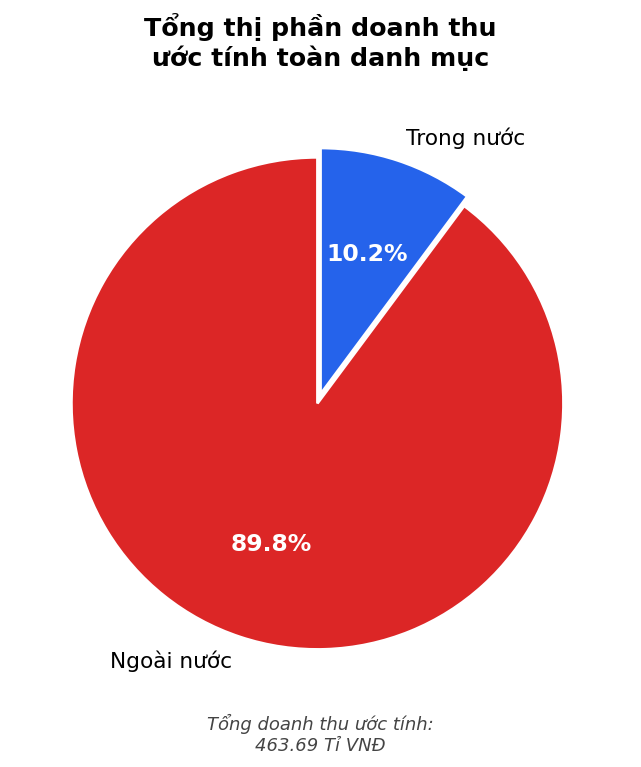

In [3]:
# 1. Chuẩn bị dữ liệu
# Sử dụng cột đã hiệu chỉnh origin_class_corrected, origin_corrected từ bước tiền xử lý (Brand Origin Mapping)
rev_by_origin = (
    df.groupby('origin_class_corrected')['estimated_revenue']
    .sum()
    .sort_values(ascending=False)
)
total_rev = rev_by_origin.sum()

# Doanh thu theo quốc gia — lấy top 8, gom phần còn lại thành "Khác"
rev_by_country_raw = (
    df.groupby('origin_corrected')['estimated_revenue']
    .sum()
    .sort_values(ascending=False)
)
top_n = 8
top_countries = rev_by_country_raw.head(top_n)
others_val    = rev_by_country_raw.iloc[top_n:].sum()
rev_by_country = pd.concat([top_countries, pd.Series({'Khác': others_val})])

# Doanh thu theo phân khúc giá × xuất xứ
price_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
df['price_segment'] = pd.Categorical(df['price_segment'], categories=price_order, ordered=True)

rev_price_origin = (
    df.groupby(['price_segment', 'origin_class_corrected'], observed=True)['estimated_revenue']
    .sum()
    .unstack(fill_value=0)
    .loc[price_order]           # đảm bảo đúng thứ tự
)

# ══════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 1: Pie chart tổng thị phần
# ══════════════════════════════════════════════════════════════════════

fig, ax1 = plt.subplots(1, 1, figsize=(6, 6))

pie_colors   = [C_IMPORT, C_DOMESTIC]
explode_vals = (0.04, 0)        # tách nhẹ miếng "Ngoài nước" để nhấn mạnh

wedges, texts, autotexts = ax1.pie(
    rev_by_origin,
    labels=rev_by_origin.index,
    colors=pie_colors,
    explode=explode_vals,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(linewidth=1.5, edgecolor='white'),
    textprops=dict(fontsize=12),
)
for at in autotexts:
    at.set(fontsize=13, fontweight='bold', color='white')

ax1.set_title('Tổng thị phần doanh thu\nước tính toàn danh mục', pad=12)

# Chú thích tổng doanh thu
total_str = f"Tổng doanh thu ước tính:\n{total_rev/1e9:.2f} Tỉ VNĐ"
ax1.text(0, -1.38, total_str, ha='center', va='center',
         fontsize=10, color='#444', style='italic')

plt.tight_layout()
plt.show()

#### **Biểu đồ 1: Tổng thị phần doanh thu (Pie chart)**

<div style="text-align: justify">

**① Thị phần tổng quát: Sự thống lĩnh của hàng ngoại nhập khẩu**

Hàng ngoại chiếm tỉ lệ **89.8%** tổng doanh thu ước tính (khoảng 620 tỉ VNĐ), trong khi hàng nội địa chỉ chiếm **10.2%** (khoảng 71 tỉ VNĐ). Sự chênh lệch này tương đương **8.7 lần**, phản ánh một hiện thực không thể phủ nhận: các nhân tố chi tiêu của người tiêu dùng Tiki đang tập trung vào thương hiệu quốc tế.

Mặc dù hàng ngoại dẫn đầu về doanh thu, dữ liệu niêm yết sản phẩm cho thấy hàng nội vẫn chiếm tỷ trọng đáng kể (~26.7%). Điều này chỉ ra rằng **sản phẩm ngoại nhập không chỉ có mức độ đa dạng cao hơn mà còn sở hữu giá trị giao dịch trung bình cao hơn hoặc tỷ lệ chuyển hóa bán hàng vượt trội** - hai chỉ báo của sức thu hút thương hiệu mạnh mẽ.

</div>

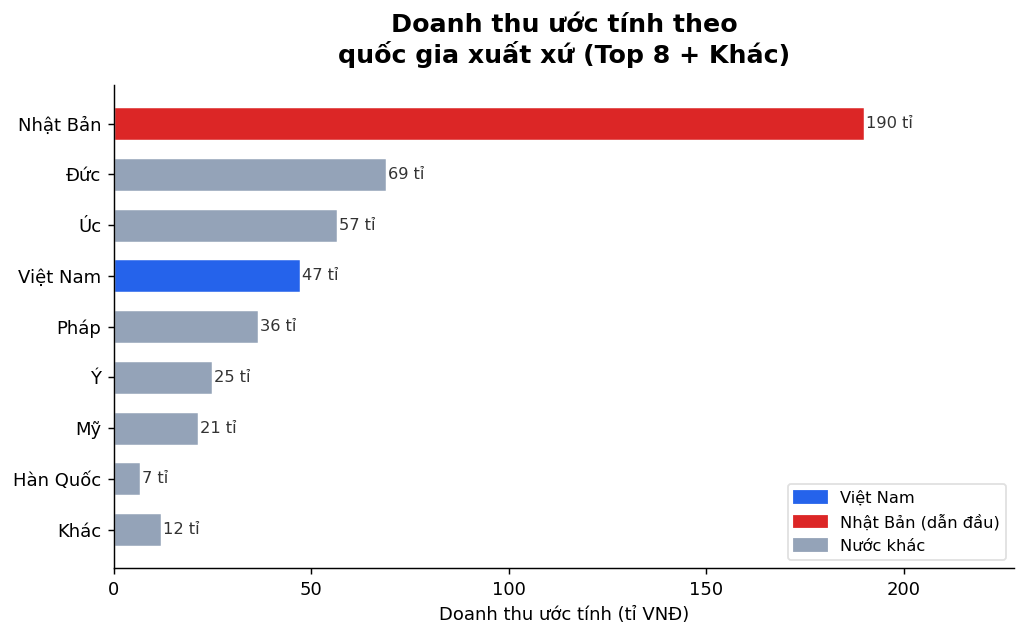

In [11]:
# ══════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 2: Bar chart doanh thu theo quốc gia
# ══════════════════════════════════════════════════════════════════════

fig, ax2 = plt.subplots(1, 1, figsize=(8, 5))

bar_colors = [C_DOMESTIC if c == 'Việt Nam' else '#94A3B8'
              for c in rev_by_country.index]
# Nổi bật thêm Japan
bar_colors = []
for c in rev_by_country.index:
    if c == 'Việt Nam':
        bar_colors.append(C_DOMESTIC)
    elif c == 'Nhật Bản':
        bar_colors.append(C_IMPORT)
    else:
        bar_colors.append('#94A3B8')

bars = ax2.barh(
    rev_by_country.index[::-1],      # đảo để top ở trên
    rev_by_country.values[::-1] / 1e9,
    color=bar_colors[::-1],
    edgecolor='white', linewidth=0.8,
    height=0.65
)

# Nhãn giá trị bên phải mỗi cột
for bar in bars:
    w = bar.get_width()
    ax2.text(w + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{w:,.0f} tỉ', va='center', ha='left', fontsize=9, color='#333')

ax2.set_xlabel('Doanh thu ước tính (tỉ VNĐ)', fontsize=10)
ax2.set_title('Doanh thu ước tính theo\nquốc gia xuất xứ (Top 8 + Khác)', pad=12)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.set_xlim(0, rev_by_country.max() / 1e9 * 1.2)

# Legend màu
patch_vn  = mpatches.Patch(color=C_DOMESTIC, label='Việt Nam')
patch_jp  = mpatches.Patch(color=C_IMPORT,   label='Nhật Bản (dẫn đầu)')
patch_oth = mpatches.Patch(color='#94A3B8',  label='Nước khác')
ax2.legend(handles=[patch_vn, patch_jp, patch_oth],
           loc='lower right', fontsize=9, framealpha=0.6)

plt.tight_layout()
plt.show()

#### **Biểu đồ 2: Doanh thu theo quốc gia xuất xứ (Bar chart)**

<div style="text-align: justify">

**② Phân bố doanh thu theo quốc gia xuất xứ: Nhật Bản giữ vị trí dẫn đầu tuyệt đối**

Nhật Bản chiếm lĩnh thị trường với doanh thu ước tính **190 tỉ VNĐ**, gấp **2 lần** so với quốc gia thứ hai (Đức, ~100 tỉ VNĐ) và **gấp 2.7 lần** so với Việt Nam (vị trí thứ tư, ~71 tỉ VNĐ). Sức hút của các thương hiệu Nhật Bản như Hada Labo, Senka, Sunplay, Acnes trên sàn Tiki là không thể bỏ qua.

Vị trí của Đức và Úc trong top 3 chủ yếu được hỗ trợ bởi các thương hiệu giá cạnh tranh cao như Nivea (Đức) và Selsun Blue (Úc), những sản phẩm có lượng bán rất lớn ở phân khúc giá thấp. Điều này chứng minh rằng **một lượng bán lớn trong phân khúc bình dân vẫn có thể tạo ra doanh thu đáng kể**. Việt Nam, mặc dù không thể cạnh tranh về quy mô với các cực cốc thị trường, vẫn duy trì sự hiện diện nhất định trong hệ sinh thái thương mại điện tử.

</div>

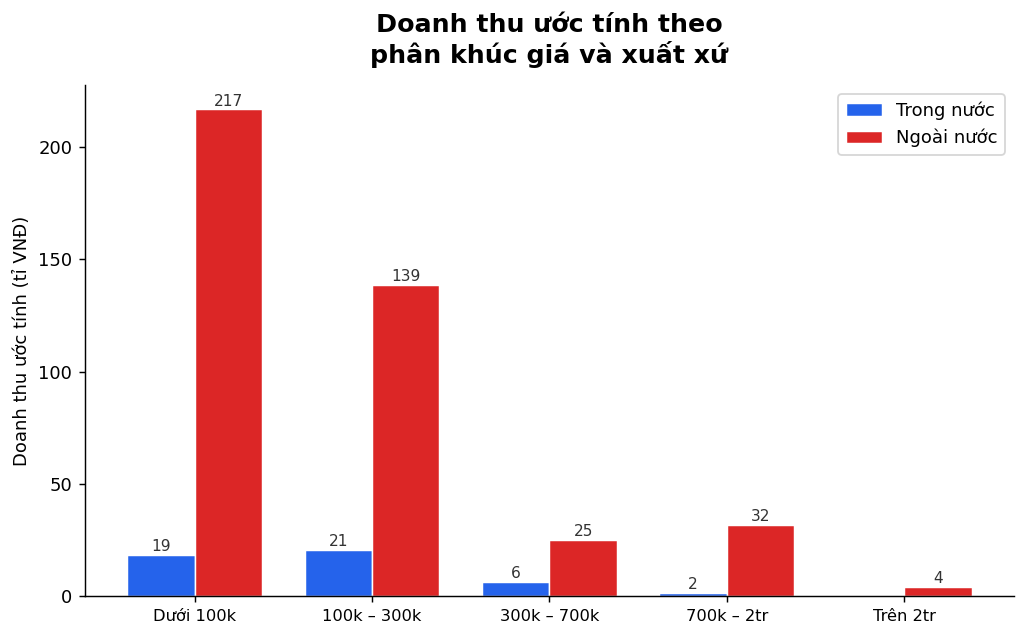

In [12]:
# ══════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 3: Grouped bar — phân khúc giá × xuất xứ
# ══════════════════════════════════════════════════════════════════════

fig, ax3 = plt.subplots(1, 1, figsize=(8, 5))

x      = np.arange(len(price_order))
width  = 0.38

bars_vn = ax3.bar(x - width/2,
                  rev_price_origin.get('Trong nước', 0) / 1e9,
                  width, label='Trong nước', color=C_DOMESTIC,
                  edgecolor='white', linewidth=0.8)
bars_nn = ax3.bar(x + width/2,
                  rev_price_origin.get('Ngoài nước', 0) / 1e9,
                  width, label='Ngoài nước', color=C_IMPORT,
                  edgecolor='white', linewidth=0.8)

# Nhãn giá trị trên đỉnh cột (chỉ hiện nếu > 0)
def label_bars(bars_group, ax, fmt='{:.0f}'):
    for bar in bars_group:
        h = bar.get_height()
        if h > 0.5:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                    fmt.format(h), ha='center', va='bottom',
                    fontsize=8.5, color='#333')

label_bars(bars_vn, ax3)
label_bars(bars_nn, ax3)

ax3.set_xticks(x)
ax3.set_xticklabels(price_order, fontsize=9)
ax3.set_ylabel('Doanh thu ước tính (tỉ VNĐ)', fontsize=10)
ax3.set_title('Doanh thu ước tính theo\nphân khúc giá và xuất xứ', pad=12)
ax3.legend(fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

#### **Biểu đồ 3: Doanh thu theo phân khúc giá (Grouped bar chart)**

<div style="text-align: justify">

**③ Cấu trúc doanh thu theo phân khúc giá: Hàng ngoại thống lĩnh trên toàn bộ phân khúc giá**

Cả hai nhóm hàng đều tập trung doanh thu trong phân khúc Dưới 100k và 100k-300k, điều này phù hợp với hành vi tiêu dùng mỹ phẩm đại trà tại Việt Nam. Tuy nhiên, đáng chú ý là ở phân khúc giá thấp (Dưới 100k), hàng ngoại vẫn duy trì ưu thế với khoảng 70% doanh thu.

**Nguyên nhân của hiện tượng này** có thể giải thích bằng việc các thương hiệu ngoại phổ thông như Selsun Blue (xã bọt), Romano (xã bọt), Dove (sữa tắm) và Sunplay (kem chống nắng) đã tích lũy được lượng bán cộng dồn và hệ thống đánh giá khá lớn qua nhiều năm, từ đó tạo thành rào cản cạnh tranh cao. Ngược lại, hàng nội địa ở phân khúc này vẫn chưa có những sản phẩm bán chạy ở mức độ tương tương để cạnh tranh hiệu quả.

Ở phân khúc cao cấp (Trên 2 triệu VNĐ), hàng nội địa gần như vắng bóng (chỉ ~5%), phản ánh rõ ràng rằng **thương hiệu nội địa vẫn chưa xây dựng được vị thế thương hiệu đủ mạnh để định vị ở phân khúc cao cấp** - một khiếm khuyết chiến lược quan trọng.

</div>

#### **Kết luận Mục tiêu 1**

<div style="text-align: justify">

Phân tích mục tiêu 1 cung cấp câu trả lời rõ ràng và có cơ sở: **hàng ngoài nhập khẩu kiểm soát phần lớn giá trị giao dịch mỹ phẩm trên sàn Tiki (89.8%, tương đương 620 tỉ VNĐ)**. Sự thống lĩnh này không giới hạn trong một phân khúc giá nào mà lan rộng từ phân khúc bình dân cho đến cao cấp. Nhật Bản nổi lên như một cực cốc thị trường có lợi thế cạnh tranh rõ nét.

Thương hiệu Việt không phải hoàn toàn mất thế với khoảng 71 tỉ VNĐ đóng góp - con số này vẫn có ý nghĩa thống kê. Tuy nhiên, **chiến lược hiện tại của thương hiệu nội địa là khai thác những phân khúc nhất định trong đó họ có lợi thế tương đối**, chứ không phải cạnh tranh trên toàn bộ thị trường. Để có bước tiến đáng kể, thương hiệu Việt cần xây dựng vị thế thương hiệu mạnh mẽ hơn, đặc biệt là trong phân khúc giá bình dân nơi có lượng tiêu thụ lớn nhất.

</div>

## **2.2. Mục tiêu 2:** Phân tích cơ cấu lượt bán và doanh thu theo từng ngành hàng (Product Type) để xác định ngành hàng nào đang dẫn dắt tăng trưởng thị trường mỹ phẩm trên Tiki.
<div style="text-align: justify">

### **2.2.1. Lí do chọn mục tiêu**
Mục tiêu 1 đã chỉ ra *ai* đang chiếm ưu thế thị phần (hàng ngoại ~89.8% doanh thu). Tuy nhiên, để hiểu đầy đủ bức tranh thị trường, cần trả lời thêm câu hỏi: *động lực tăng trưởng đang đến từ ngành hàng nào?* Một ngành có thể dẫn đầu về doanh thu nhưng lại không dẫn đầu về lượt bán - hai chiều này phản ánh hai loại "sức mạnh" khác nhau: giá trị giao dịch vs. độ phổ biến đại trà. Việc phân tích đồng thời cả hai chiều theo từng ngành hàng giúp xác định đúng "động cơ" vận hành thị trường, đồng thời làm nền tảng để Mục tiêu 3 đặt câu hỏi: trong các ngành hàng đó, thương hiệu Việt đang cạnh tranh ở đâu?
### **2.2.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể:** Phân tích, truy vấn.

**Biểu đồ lựa chọn:**
- **Biểu đồ cột nhóm (Grouped bar chart):** Đặt hai cột lượt bán và doanh thu cạnh nhau cho từng ngành hàng, giúp phát hiện ngay sự chênh lệch giữa hai chiều đo lường - một biểu đồ duy nhất trả lời được cả hai câu hỏi.
- **Biểu đồ tròn phân cấp / Treemap (theo ngành + top category):** Thể hiện trực quan cấu trúc thị trường - ngành nào to, ngành nào nhỏ, và trong mỗi ngành thì danh mục nào đang kéo số.
- **Biểu đồ cột ngang (Horizontal bar) phân tầng phổ biến:** Hiển thị tỉ lệ Bestseller / Bán chạy / Mới trong mỗi ngành, cho biết ngành nào có sản phẩm "chín" (đã tích lũy lượt bán) và ngành nào còn non.

</div>

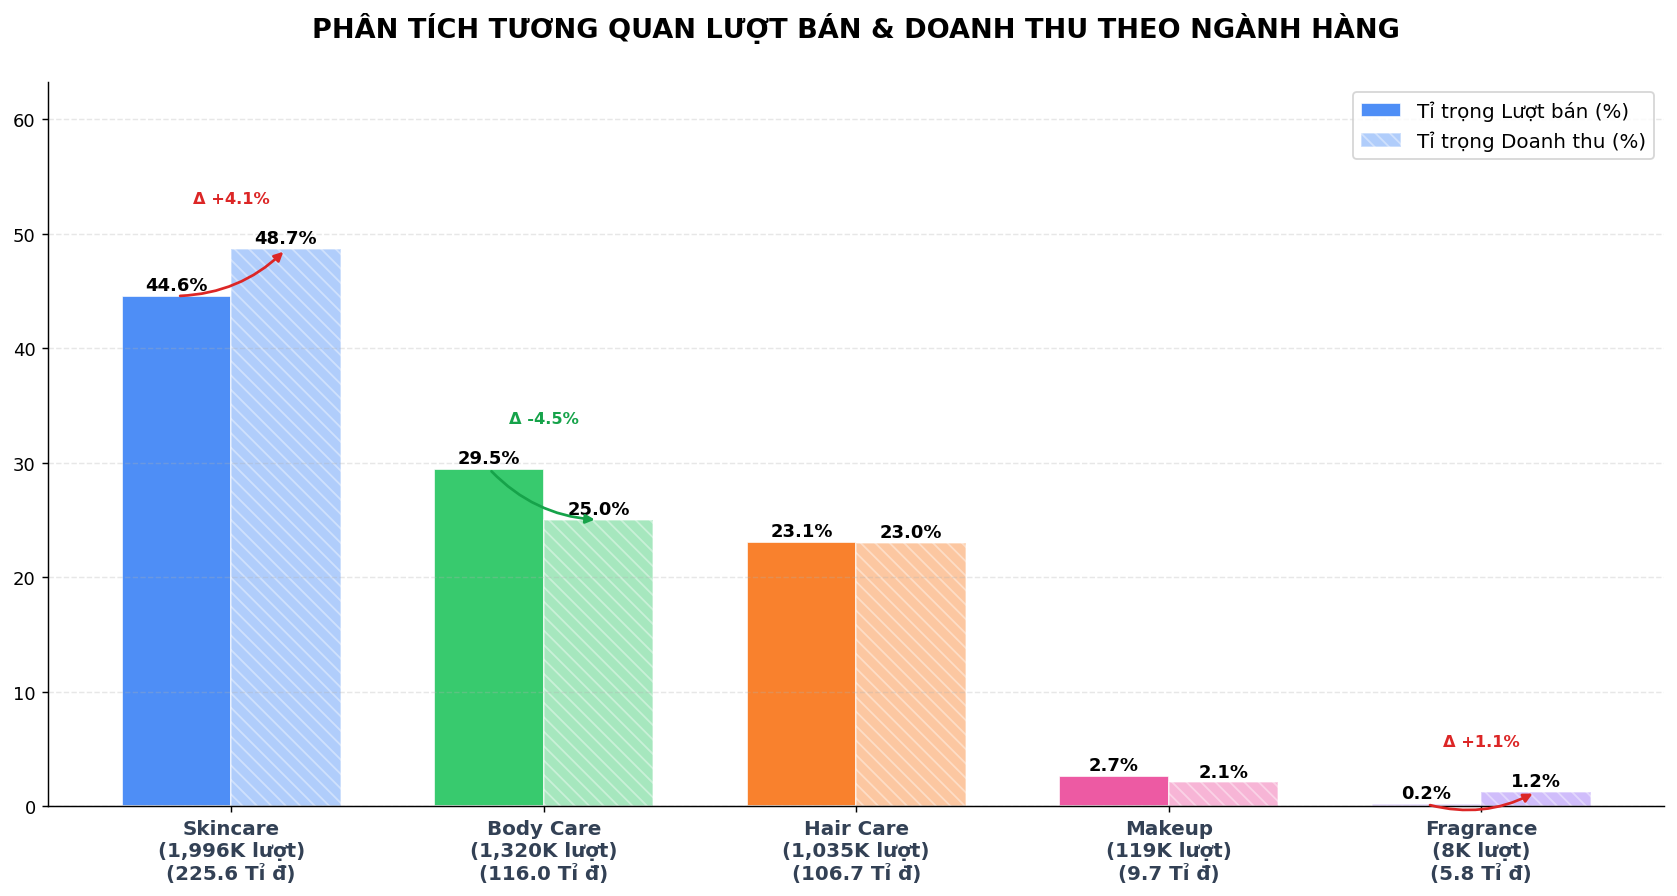

In [6]:
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# ── 1. Chuẩn bị dữ liệu ─────────────────────────────────────
# Tổng hợp theo 5 ngành hàng chính
grp = (
    df.groupby('product_type')
    .agg(
        n_products    = ('product_id',       'count'),
        total_sold    = ('sold_count',        'sum'),
        total_rev     = ('estimated_revenue', 'sum'),
    )
    .sort_values('total_rev', ascending=False)
    .reset_index()
)
grp['rev_share']     = grp['total_rev']  / grp['total_rev'].sum()  * 100
grp['sold_share']    = grp['total_sold'] / grp['total_sold'].sum() * 100
grp['product_share'] = grp['n_products'] / grp['n_products'].sum() * 100

# Top 4 category theo doanh thu trong mỗi ngành (cho treemap-style bar)
top_cats = (
    df.groupby(['product_type', 'category'])
    .agg(cat_sold=('sold_count','sum'), cat_rev=('estimated_revenue','sum'))
    .reset_index()
    .sort_values(['product_type', 'cat_rev'], ascending=[True, False])
    .groupby('product_type')
    .head(4)
)

# Tỉ lệ popularity tier theo ngành
tier_order  = ['Bestseller', 'Bán chạy', 'Phổ biến', 'Mới', 'Chưa có lượt bán']
tier_colors = ['#1D4ED8', '#60A5FA', '#93C5FD', '#E2E8F0', '#CBD5E1']
pop_pct = (
    pd.crosstab(df['product_type'], df['popularity_tier'], normalize='index') * 100
)[tier_order].loc[grp['product_type']]   # giữ thứ tự theo doanh thu

# Màu riêng cho từng ngành
TYPE_COLORS = {
    'Skincare' : '#3B82F6',
    'Body Care': '#22C55E',
    'Hair Care': '#F97316',
    'Makeup'   : '#EC4899',
    'Fragrance': '#8B5CF6',
}

# ═══════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 1: Grouped bar — Lượt bán vs Doanh thu theo Ngành hàng
# ═══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(13, 7))

n_types = len(grp)
x = np.arange(n_types)
w = 0.35

# Cột lượt bán (màu đậm) và doanh thu (màu nhạt hơn)
sold_bars = ax.bar(x - w/2, grp['sold_share'], width=w, label='Tỉ trọng Lượt bán (%)',
                        color=[TYPE_COLORS[t] for t in grp['product_type']], alpha=0.9, edgecolor='white', lw=1)
rev_bars  = ax.bar(x + w/2, grp['rev_share'], width=w, label='Tỉ trọng Doanh thu (%)',
                        color=[TYPE_COLORS[t] for t in grp['product_type']], alpha=0.4, hatch='\\\\\\', edgecolor='white', lw=1)

# Nhãn giá trị trên cột
for i, row in grp.iterrows():
    # Nhãn % trên đầu
    ax.text(i - w/2, row['sold_share'] + 0.5, f"{row['sold_share']:.1f}%", ha='center', fontsize=10, fontweight='bold')
    ax.text(i + w/2, row['rev_share'] + 0.5, f"{row['rev_share']:.1f}%", ha='center', fontsize=10, fontweight='bold')
    
    # Mũi tên Delta (Chỉ vẽ nếu chênh lệch đáng kể)
    diff = row['rev_share'] - row['sold_share']
    if abs(diff) > 1:
        color_d = '#DC2626' if diff > 0 else '#16A34A'
        
        ax.annotate('', xy=(i + w/2, row['rev_share']), xytext=(i - w/2, row['sold_share']),
                         arrowprops=dict(arrowstyle='-|>', color=color_d, lw=1.5, connectionstyle="arc3,rad=.2"))
        ax.text(i, max(row['sold_share'], row['rev_share']) + 4, f"Δ {diff:+.1f}%", 
                     ha='center', color=color_d, fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))


ax.set_xticks(x)
xtick_labels = [f"{t}\n({grp.loc[i, 'total_sold']/1e3:,.0f}K lượt)\n({grp.loc[i, 'total_rev']/1e9:.1f} Tỉ đ)" 
                for i, t in enumerate(grp['product_type'])]
ax.set_xticklabels(xtick_labels, fontsize=11, fontweight='bold', color='#334155')

ax.set_title('PHÂN TÍCH TƯƠNG QUAN LƯỢT BÁN & DOANH THU THEO NGÀNH HÀNG', fontsize=15, fontweight='bold', pad=25)
ax.set_ylim(0, max(grp['sold_share'].max(), grp['rev_share'].max()) * 1.3)
ax.legend(loc='upper right', fontsize=11, frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### **Biểu đồ 1: Phân tích tương quan lượt bán & doanh thu (Grouped bar chart)**

<div style="text-align: justify">

**① Cơ cấu tổng thể - ai đang kéo thị trường?**

Skincare là ngành hàng vượt trội tuyệt đối: chiếm **52.8% số sản phẩm**, **44.6% lượt bán** và **48.7% doanh thu** - một ngành hàng dẫn đầu trên cả ba chiều đo lường. Đây là "động cơ chính" của thị trường mỹ phẩm Tiki.
Body Care và Hair Care xếp thứ hai và ba, mỗi ngành chiếm khoảng **23–25% lượt bán và doanh thu** - hai ngành này cân bằng nhau về quy mô nhưng đều có tỉ trọng lượt bán cao hơn tỉ trọng doanh thu nhẹ, cho thấy đây là các sản phẩm tiêu dùng đại trà, giá trung bình thấp hơn.

**② Sự phân kỳ giữa lượt bán và doanh thu (mũi tên Δ)**

Hai trường hợp đáng chú ý:
- **Fragrance: Δ = +1.08%** - ngành này chỉ có **0.2% lượt bán** nhưng chiếm đến **1.2% doanh thu**, tỉ lệ doanh thu/lượt bán cao nhất thị trường. Lý do: giá nước hoa trung bình rất cao (~1.3 triệu đ/sản phẩm), mỗi giao dịch ít nhưng giá trị lớn.
- **Skincare: Δ = +4.1%** - tỉ trọng doanh thu vượt tỉ trọng lượt bán đáng kể, phản ánh mức giá trung bình cao (~730k đ) và sức mua mạnh của nhóm khách hàng skincare.

</div>

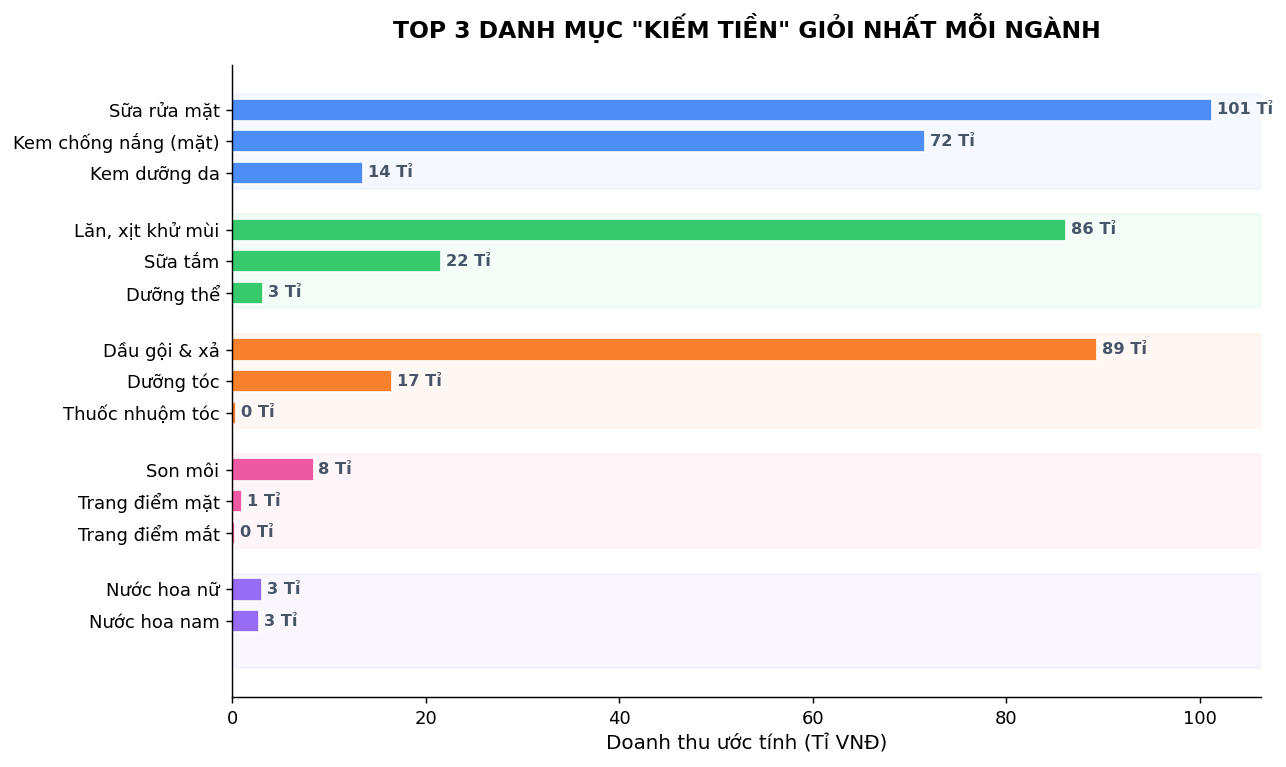

In [14]:
# ═══════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 2: Top category bar ngang theo ngành
# ═══════════════════════════════════════════════════════════════════════

fig, ax_cat = plt.subplots(figsize=(10, 6))

y_pos, y_label, x_vals, colors = [], [], [], []
offset = 0
for pt in grp['product_type']:
    cats = top_cats[top_cats['product_type'] == pt].head(3)
    # Vẽ dải nền mờ để phân nhóm ngành
    ax_cat.axhspan(offset - 0.5, offset + 2.5, color=TYPE_COLORS[pt], alpha=0.05)
    for _, row in cats.iterrows():
        y_pos.append(offset)
        y_label.append(row['category'])
        x_vals.append(row['cat_rev'] / 1e9)
        colors.append(TYPE_COLORS[pt])
        offset += 1
    offset += 0.8 # Khoảng trống giữa các nhóm ngành

bars_c = ax_cat.barh(y_pos, x_vals, color=colors, height=0.7, edgecolor='white', alpha=0.9)
ax_cat.set_yticks(y_pos)
ax_cat.set_yticklabels(y_label, fontsize=10)
ax_cat.invert_yaxis()

# Nhãn doanh thu cuối thanh
for bar in bars_c:
    ax_cat.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.0f} Tỉ", 
                va='center', fontsize=9, fontweight='bold', color='#475569')

ax_cat.set_title('TOP 3 DANH MỤC "KIẾM TIỀN" GIỎI NHẤT MỖI NGÀNH', fontsize=13, fontweight='bold', pad=15)
ax_cat.set_xlabel('Doanh thu ước tính (Tỉ VNĐ)', fontsize=11)
ax_cat.spines['right'].set_visible(False)
ax_cat.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

#### **Biểu đồ 2: Top 3 danh mục theo ngành hàng (Horizontal bar chart)**

<div style="text-align: justify">

**③ Danh mục "đầu tàu" trong từng ngành**

Không phải toàn bộ ngành đều đóng góp đều - trong hầu hết ngành, 1–2 danh mục chiếm phần lớn doanh thu:
- **Skincare:** Sữa rửa mặt (~101 tỉ) và Kem chống nắng mặt (~72 tỉ) tạo ra hơn 76% doanh thu toàn ngành.
- **Body Care:** Lăn/xịt khử mùi (~86 tỉ) một mình chiếm ~74% doanh thu toàn ngành Body Care - tập trung cực kỳ cao.
- **Hair Care:** Dầu gội & xả (~89 tỉ) chiếm ~84% doanh thu ngành.
- **Makeup:** Son môi (~8.4 tỉ) áp đảo tuyệt đối với >87% doanh thu ngành.

</div>

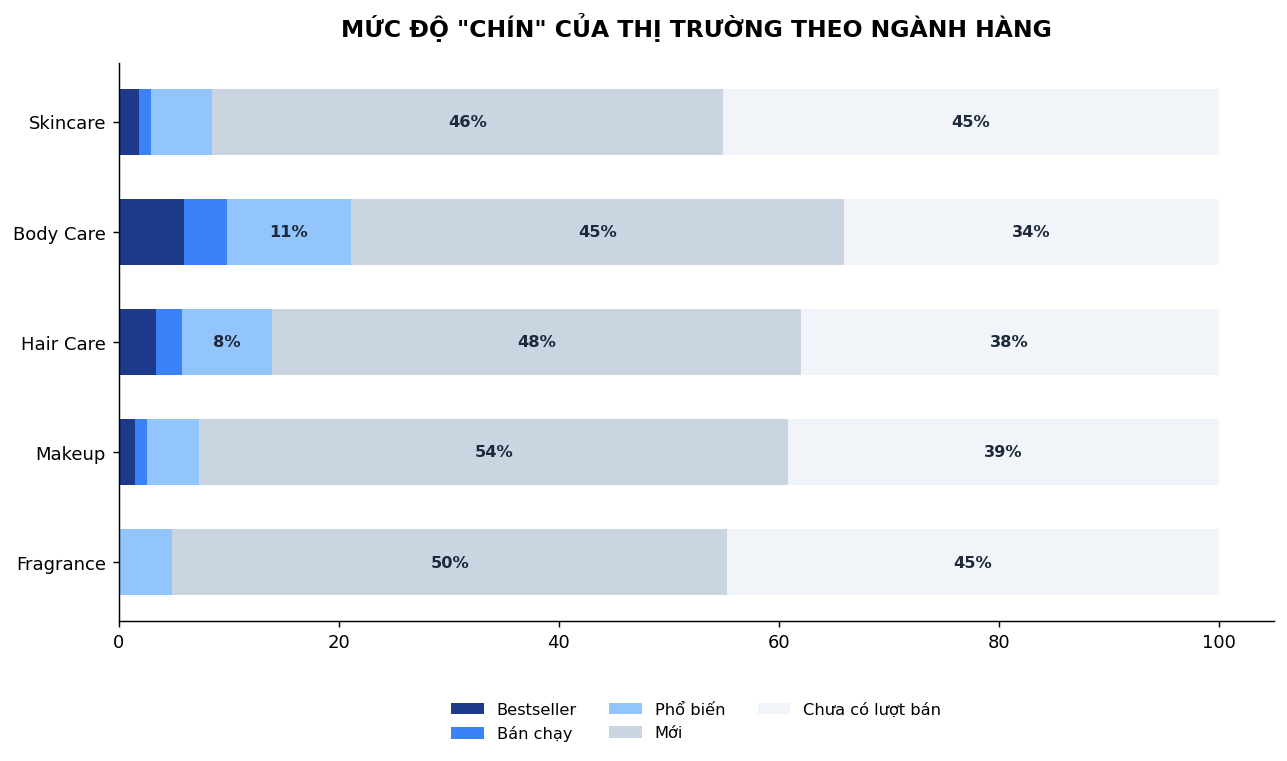

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 3: Stacked bar — Popularity Tier
# ═══════════════════════════════════════════════════════════════════════

fig, ax_tier = plt.subplots(figsize=(10, 6))

n_types = len(grp)
tier_colors_v2 = ['#1E3A8A', '#3B82F6', '#93C5FD', '#CBD5E1', '#F1F5F9']
left_vals = np.zeros(n_types)

for tier, color in zip(tier_order, tier_colors_v2):
    vals = pop_pct[tier].values
    bars = ax_tier.barh(grp['product_type'], vals, left=left_vals, color=color, label=tier, height=0.6)
    for bar, v in zip(bars, vals):
        if v > 7:
            ax_tier.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                         f'{v:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold', 
                         color='white' if color == '#1E3A8A' else '#1E293B')
    left_vals += vals

ax_tier.set_title('MỨC ĐỘ "CHÍN" CỦA THỊ TRƯỜNG THEO NGÀNH HÀNG', fontsize=13, fontweight='bold', pad=15)
ax_tier.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9, frameon=False)
ax_tier.invert_yaxis()
ax_tier.spines['right'].set_visible(False)
ax_tier.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

#### **Biểu đồ 3: Mức độ "chín" của sản phẩm (Stacked bar chart)**

<div style="text-align: justify">

**④ Mức độ "chín" của sản phẩm theo ngành hàng**

Body Care có tỉ lệ **Bestseller + Bán chạy cao nhất (~9.8%)**, phản ánh thị trường này đã hình thành rõ ràng với một số sản phẩm thống lĩnh ổn định (Selsun, Romano, Dove...). Ngược lại, Fragrance và Skincare có hơn **44–45% sản phẩm chưa có lượt bán nào** - thị trường còn rất phân mảnh, nhiều sản phẩm mới gia nhập nhưng chưa có chỗ đứng.

</div>

#### **Kết luận Mục tiêu 2**

<div style="text-align: justify">

Thị trường mỹ phẩm trên Tiki vận hành theo nguyên tắc "20/80" rõ nét: **Skincare là ngành hàng duy nhất dẫn đầu trên cả ba chiều** (sản phẩm, lượt bán, doanh thu) và là động lực tăng trưởng cốt lõi. Body Care và Hair Care đóng góp lớn về lượng nhưng giá trị giao dịch thấp hơn. Fragrance là ngành ngách có giá trị đơn hàng cao nhất nhưng khối lượng giao dịch rất hạn chế. Kết quả này đặt nền tảng trực tiếp cho Mục tiêu 3: trong bức tranh ngành hàng vừa xác lập, thương hiệu Việt đang cạnh tranh hiệu quả ở những phân khúc nào?

</div>

## **2.3. Mục tiêu 3:** Xây dựng chỉ số “Sức mạnh nội địa” theo từng nhóm ngành hàng (Product Type) để xác định các phân khúc ưu thế của thương hiệu Việt.
### **2.3.1. Lí do chọn mục tiêu** 
<div style="text-align: justify">

Mục tiêu 1 cho thấy hàng ngoại chiếm ~89.8% doanh thu toàn thị trường - một con số áp đảo. Mục tiêu 2 chỉ ra Skincare, Body Care và Hair Care là ba ngành hàng đang kéo phần lớn lượt bán và doanh thu. Tuy nhiên, hai kết quả đó mới chỉ phác thảo bức tranh tổng thể, chưa trả lời được câu hỏi quan trọng hơn: **liệu hàng Việt có thực sự thua trên toàn bộ thị trường, hay chỉ đang bị "kéo xuống" bởi những ngành mà thương hiệu quốc tế vốn đã quá mạnh?**

Thực tế thị trường mỹ phẩm rất phân mảnh - hoàn toàn có thể tồn tại những ngành hàng mà thương hiệu nội địa đang cạnh tranh tốt hoặc thậm chí chiếm ưu thế, nhưng bị che khuất bởi con số tổng hợp. Mục tiêu này tập trung làm rõ điều đó bằng cách xây dựng chỉ số **"Sức mạnh nội địa" (Domestic Strength Index - DSI)** - đo lường đồng thời ba chiều: tỉ lệ lượt bán, tỉ lệ doanh thu và tỉ lệ số sản phẩm của hàng Việt trong từng ngành - để định lượng chính xác nơi nào thương hiệu Việt đang thực sự có chỗ đứng.
### **2.3.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể:** Truy vấn.

**Biểu đồ lựa chọn:**
- **Radar chart (Spider chart):** lý tưởng để hiển thị đa chiều - so sánh cùng lúc 3 chiều (lượt bán, doanh thu, sản phẩm) của 5 ngành hàng trên một biểu đồ duy nhất.
- **Stacked bar chart ngang:** hiển thị cấu trúc nội/ngoại trong mỗi ngành hàng theo lượt bán, giúp thấy rõ sự phân hóa giữa các ngành.

</div>

#### **Biểu đồ 1: Radar chart - Sức mạnh nội địa (DSI)**

<div style="text-align: justify">

**① Radar chart - Bức tranh tổng thể theo ngành hàng:**

Biểu đồ radar phơi bày một sự phân hóa rất rõ nét: trong 5 ngành hàng, chỉ duy nhất **Makeup** có diện tích radar đáng kể, trong khi 4 ngành còn lại đều co lại thành một hình rất nhỏ sát tâm.

**Makeup** là ngoại lệ nổi bật - sold_share đạt ~87.8% và rev_share ~76.4%. Điểm đáng chú ý là product_share của hàng nội trong ngành này chỉ ~12.1%, tức không phải vì hàng Việt "nhiều" mà vì chúng **bán rất tốt**: một lượng sản phẩm khiêm tốn đang tạo ra phần lớn giao dịch toàn ngành. Đây là dấu hiệu của sự tập trung cao - một vài thương hiệu nội địa như Cocoon, Emmié by Happy Skin đang hoạt động cực kỳ hiệu quả thay vì dàn trải. Về doanh thu, mặc dù rev_share ~76.4% là cao, khoảng cách 11 điểm phần trăm so với sold_share (~87.8%) cho thấy giá trị đơn hàng trung bình của hàng ngoại trong ngành này vẫn cao hơn hàng nội - người mua Makeup ngoại tuy ít hơn nhưng chi nhiều hơn mỗi lần mua.

Với 4 ngành còn lại, ba chiều DSI đều rất thấp và gần bằng nhau, hàm ý hàng ngoại không chỉ thắng về lượt bán hay doanh thu mà còn áp đảo ngay cả về số lượng sản phẩm niêm yết. Điều này có nghĩa rào cản gia nhập của hàng Việt ở những ngành này không chỉ là vấn đề bán hàng mà còn là vấn đề **hiện diện** trên sàn.

</div>

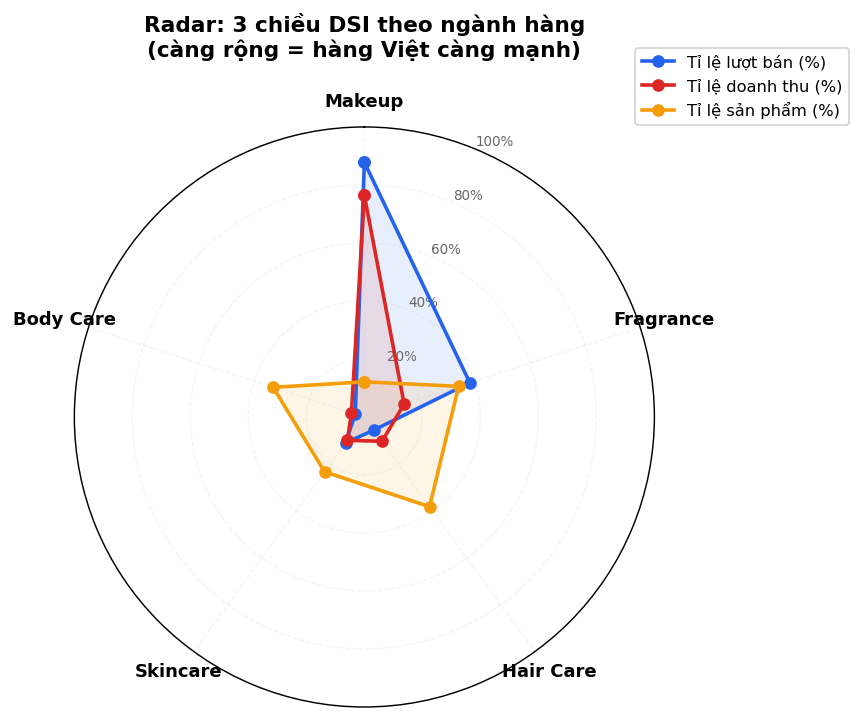

In [16]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

# 1. Tính DSI theo Product Type
product_types = df['product_type'].unique()

grp_type = df.groupby('product_type').agg(
    total_sold    = ('sold_count', 'sum'),
    total_rev     = ('estimated_revenue', 'sum'),
    total_products= ('product_id', 'count')
).reset_index()

dom_type = (
    df[df['origin_class_corrected'] == 'Trong nước']
    .groupby('product_type').agg(
        dom_sold    = ('sold_count', 'sum'),
        dom_rev     = ('estimated_revenue', 'sum'),
        dom_products= ('product_id', 'count')
    ).reset_index()
)

dsi_df = grp_type.merge(dom_type, on='product_type', how='left').fillna(0)
dsi_df['sold_share']    = dsi_df['dom_sold']     / dsi_df['total_sold']     * 100
dsi_df['rev_share']     = dsi_df['dom_rev']      / dsi_df['total_rev']      * 100
dsi_df['product_share'] = dsi_df['dom_products'] / dsi_df['total_products'] * 100
dsi_df['DSI']           = (dsi_df['sold_share'] + dsi_df['rev_share'] + dsi_df['product_share']) / 3
dsi_df = dsi_df.sort_values('DSI', ascending=False)

# Chuẩn bị dữ liệu cho radar chart
categories_radar = dsi_df['product_type'].tolist()
N = len(categories_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]   # đóng vòng

# Ba chiều của DSI
metrics = {
    'Tỉ lệ lượt bán (%)' : dsi_df['sold_share'].tolist(),
    'Tỉ lệ doanh thu (%)': dsi_df['rev_share'].tolist(),
    'Tỉ lệ sản phẩm (%)' : dsi_df['product_share'].tolist(),
}
metric_colors = [C_DOMESTIC, C_IMPORT, '#F59E0B']

# Chuẩn bị dữ liệu cho stacked bar
dsi_sorted = dsi_df.sort_values('DSI')
dom_vals   = dsi_sorted['dom_sold'].values
imp_vals   = (dsi_sorted['total_sold'] - dsi_sorted['dom_sold']).values
types      = dsi_sorted['product_type'].values

# ═══════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 1: Radar chart DSI
# ═══════════════════════════════════════════════════════════════════════

fig, ax_radar = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories_radar, fontsize=10, fontweight='bold')
ax_radar.set_ylim(0, 100)
ax_radar.set_yticks([20, 40, 60, 80, 100])
ax_radar.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=7.5, color='#666')
ax_radar.grid(color='#CBD5E1', linestyle='--', linewidth=0.7)

for (metric_name, values), color in zip(metrics.items(), metric_colors):
    vals = values + values[:1]
    ax_radar.plot(angles, vals, 'o-', linewidth=2, color=color, label=metric_name)
    ax_radar.fill(angles, vals, alpha=0.10, color=color)

ax_radar.set_title('Radar: 3 chiều DSI theo ngành hàng\n(càng rộng = hàng Việt càng mạnh)',
                   pad=20, fontsize=12)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.show()

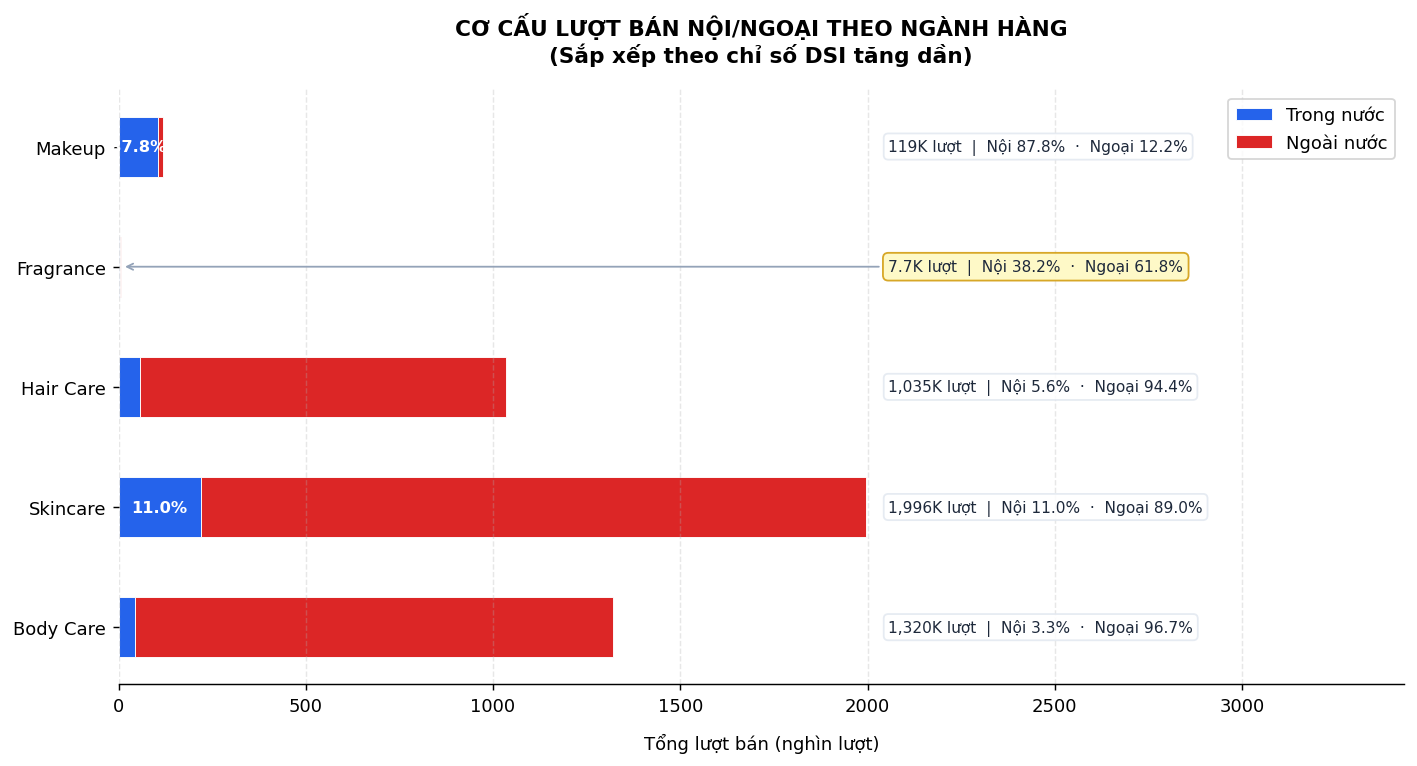

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ 2: Stacked bar — Cấu trúc lượt bán nội/ngoại theo ngành
# ═══════════════════════════════════════════════════════════════════════

fig, ax_stack = plt.subplots(figsize=(11, 6))

max_val  = dsi_sorted['total_sold'].max() / 1e3
text_x   = max_val * 1.03

bars_d = ax_stack.barh(types, dom_vals / 1e3, color=C_DOMESTIC,
                        label='Trong nước', height=0.5, edgecolor='white', linewidth=0.5)
bars_i = ax_stack.barh(types, imp_vals / 1e3, left=dom_vals / 1e3,
                        color=C_IMPORT, label='Ngoài nước', height=0.5, edgecolor='white', linewidth=0.5)

for i, (d, t, tp) in enumerate(zip(dom_vals, dsi_sorted['total_sold'].values, types)):
    pct     = d / t * 100 if t > 0 else 0
    total_k = t / 1e3
    bar_len = total_k / max_val

    
    if pct > 8 and bar_len > 0.05:
        ax_stack.text((d / 1e3) / 2, i,
                      f'{pct:.1f}%',
                      ha='center', va='center',
                      fontsize=9, fontweight='bold', color='white')

    # Annotation đồng bộ bên phải — tất cả các ngành
    if bar_len < 0.05:
        ax_stack.annotate(
            f'{total_k:.1f}K lượt  |  Nội {pct:.1f}%  ·  Ngoại {100-pct:.1f}%',
            xy=(total_k, i),
            xytext=(text_x, i),
            fontsize=8.5, color='#1E293B', va='center',
            arrowprops=dict(arrowstyle='->', color='#94A3B8',
                            lw=1.0, connectionstyle='arc3,rad=0.0'),
            bbox=dict(boxstyle='round,pad=0.35',
                      facecolor='#FEF9C3', edgecolor='#D4A017', alpha=0.92)
        )
    else:
        
        ax_stack.text(
            text_x, i,
            f'{total_k:,.0f}K lượt  |  Nội {pct:.1f}%  ·  Ngoại {100-pct:.1f}%',
            ha='left', va='center',
            fontsize=8.5, color='#1E293B',
            bbox=dict(boxstyle='round,pad=0.30',
                      facecolor='white', edgecolor='#E2E8F0', alpha=0.85)
        )


ax_stack.set_xlim(0, max_val * 1.72)

ax_stack.set_xlabel('Tổng lượt bán (nghìn lượt)', fontsize=10, labelpad=10)
ax_stack.set_title('CƠ CẤU LƯỢT BÁN NỘI/NGOẠI THEO NGÀNH HÀNG\n(Sắp xếp theo chỉ số DSI tăng dần)',
                   fontsize=12, fontweight='bold', pad=15)
ax_stack.legend(fontsize=10, loc='upper right', frameon=True, shadow=False)
ax_stack.spines['top'].set_visible(False)
ax_stack.spines['right'].set_visible(False)
ax_stack.spines['left'].set_visible(False)
ax_stack.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### **Biểu đồ 2: Stacked bar - Cơ cấu lượt bán nội/ngoại**

<div style="text-align: justify">

**② Stacked bar - Cơ cấu lượt bán tuyệt đối:**

Nhìn vào giá trị tuyệt đối, bức tranh thêm phần phức tạp. **Skincare** dẫn đầu với gần **2 triệu lượt bán** toàn ngành, trong đó hàng nội chỉ chiếm ~11% (~220 nghìn lượt). Dù tỉ lệ thấp, con số tuyệt đối này vẫn lớn hơn toàn bộ lượt bán của ngành Makeup (~119 nghìn lượt). Điều này cho thấy đánh giá "mạnh" hay "yếu" phụ thuộc vào cách đo: hàng Việt trong Skincare yếu về **tỉ lệ** nhưng không hề nhỏ về **khối lượng**.

**Body Care** và **Hair Care** có tổng lượt bán rất lớn (~1.3 triệu và ~1 triệu lượt), nhưng tỉ lệ nội địa chỉ 3–6%. Đây là hai ngành mà một số ít thương hiệu ngoại thống lĩnh gần như tuyệt đối - trong Hair Care là Selsun và Romano; trong Body Care là Clear, Dove, Lifebuoy. Các thương hiệu này đã tích lũy lượt bán và review rất lớn qua nhiều năm, tạo thành rào cản cạnh tranh cực kỳ cao cho bất kỳ thương hiệu nội địa nào muốn gia nhập.

**Fragrance** là trường hợp cần đọc thận trọng nhất. DSI ~28.9% nghe có vẻ khá, nhưng tổng lượt bán toàn ngành chỉ ~7.700 lượt - nhỏ nhất trong 5 ngành, cách Skincare tới 260 lần. Hơn nữa, một phần đáng kể trong số ~38% sản phẩm nội địa của ngành này là nước hoa chiết hoặc nước hoa phỏng theo thương hiệu nước ngoài, được đăng ký dưới tên thương hiệu nội địa. DSI cao của Fragrance vì vậy phản ánh đặc thù cấu trúc ngành hơn là năng lực cạnh tranh thực sự của thương hiệu Việt.

</div>

#### **Kết luận Mục tiêu 3**

<div style="text-align: justify">

Đặt cạnh kết quả Mục tiêu 1 và Mục tiêu 2, DSI làm rõ một nghịch lý đáng suy ngẫm: thương hiệu Việt đang mạnh nhất ở **Makeup** - ngành có tổng lượt bán thấp nhất (~119 nghìn lượt) và chỉ chiếm ~2.1% doanh thu toàn thị trường - trong khi gần như vắng mặt ở **Skincare**, ngành chiếm gần một nửa doanh thu và dẫn đầu lượt bán toàn sàn. Nói cách khác, thương hiệu Việt đang chiến thắng ở đúng những ngành mà tầm quan trọng thị trường thấp nhất, và thua ở đúng những ngành lớn nhất.

Điều này không đơn thuần là vấn đề năng lực sản phẩm - trong Makeup, hàng Việt hoàn toàn chứng minh được khả năng cạnh tranh và chiếm lĩnh thị trường. Vấn đề nằm ở **định vị chiến lược**: để tăng tổng thị phần nội địa một cách thực chất, thương hiệu Việt cần thâm nhập vào Skincare và Hair Care - hai ngành lớn đang bị hàng ngoại, đặc biệt Nhật Bản và Đức, kiểm soát chặt chẽ. Đó là bài toán khó hơn nhiều so với việc tiếp tục củng cố vị thế trong Makeup, nhưng cũng là con đường duy nhất để thay đổi bức tranh tổng thể.

</div>